# 02 - AI4I Statistical Validation Updated

This notebook statistically validates the AI4I interventions used in the deployment-oriented evaluation methodology.

## Research role

The notebook does **not** claim that repeating experiments improves the underlying model. Instead, repeated seeds are used to estimate variability and test whether paired differences between configurations are consistently supported.

## Main questions addressed

- Which intervention produced each observed difference?
- Are paired differences consistent across repeated train/validation/test splits?
- What is the practical magnitude of each difference?
- Does statistical significance agree with practical direction?
- How do class weighting, cost-sensitive thresholding, SMOTE, Platt calibration and isotonic calibration affect predictive quality, probability reliability and assumed operational penalty?

## Interpretation boundaries

- Statistical significance does not establish novelty.
- Twenty seeds improve uncertainty estimation, not model performance.
- Operational cost is an assumed asymmetric penalty score, not a monetary amount.
- The same validation split is used for calibration fitting and threshold selection because AI4I contains few positive samples; this limitation must be reported.

## Environment and Global Configuration

In [ ]:
# Install required package
!pip -q install xgboost imbalanced-learn statsmodels scipy

In [ ]:
# Import libraries

import os, sys, json, time, platform, tempfile, warnings
import joblib, psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, brier_score_loss, log_loss

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

# Imbalanced learning utilities
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")

In [ ]:
# Output directories for all experiment artefacts
OUT = Path("ai4i_ipmef_validation_outputs")
FIG = OUT / "figures"
THRESHOLD_DIR = OUT / "threshold_searches"
MODEL_DIR = OUT / "models"

for directory in [OUT, FIG, THRESHOLD_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Global random seeds for repeated 20‑seed ablation
SEEDS = [
    42, 100, 2024, 1234, 9999,
    7, 21, 77, 314, 2025,
    11, 55, 88, 144, 512,
    777, 909, 1337, 2048, 4096,
]

# Operational penalty assumptions (FP=1, FN=10)
FP_PENALTY = 1.0
FN_PENALTY = 10.0

# Bootstrap and latency measurement configuration
BOOTSTRAP_SAMPLES = 10_000
LATENCY_WARMUPS = 5
LATENCY_REPEATS = 30
SINGLE_SAMPLE_LATENCY_REPEATS = 100

# Dataset URL (AI4I 2020)
DATA_URL = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/00601/ai4i2020.csv"
)

# Ensure reproducibility for Python hashing
os.environ["PYTHONHASHSEED"] = str(SEEDS[0])

print("Output directory:", OUT.resolve())

Output directory: /content/ai4i_ipmef_validation_outputs


In [ ]:
# Save environment metadata for reproducibility==
environment = {
    "python_version": sys.version,
    "platform": platform.platform(),
    "processor": platform.processor(),
    "logical_cpu_count": psutil.cpu_count(logical=True),
    "physical_cpu_count": psutil.cpu_count(logical=False),
    "ram_gb": round(psutil.virtual_memory().total / (1024 ** 3), 2),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
}

# Save experiment configuration (seeds, penalties, hypotheses)
experiment_configuration = {
    "seeds": SEEDS,
    "fp_penalty": FP_PENALTY,
    "fn_penalty": FN_PENALTY,
    "bootstrap_samples": BOOTSTRAP_SAMPLES,
    "latency_warmups": LATENCY_WARMUPS,
    "latency_repeats": LATENCY_REPEATS,
    "single_sample_latency_repeats": SINGLE_SAMPLE_LATENCY_REPEATS,
    "data_url": DATA_URL,
    "statistical_null_hypothesis": (
        "For each paired comparison and metric, "
        "the median paired difference equals zero."
    ),
    "statistical_alternative_hypothesis": (
        "For each paired comparison and metric, "
        "the median paired difference differs from zero."
    ),
    "important_interpretation": (
        "Repeated seeds estimate variability and paired differences. "
        "They do not improve the underlying classifier."
    ),
}

with open(
    OUT / "execution_environment.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(environment, file, indent=2)

with open(
    OUT / "experiment_configuration.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(experiment_configuration, file, indent=2)

display(
    pd.DataFrame([environment])
    .T
    .rename(columns={0: "Value"})
)

,Value
python_version,"3.12.13 (main, Mar 4 2026, 09:23:07) [GCC 11...."
platform,Linux-6.6.122+-x86_64-with-glibc2.35
processor,x86_64
logical_cpu_count,2
physical_cpu_count,1
ram_gb,12.67
numpy_version,2.0.2
pandas_version,2.2.2


## Dataset and leakage control

This section loads the AI4I 2020 predictive‑maintenance dataset and applies strict leakage control.  
The goal is to ensure that all downstream statistical validation reflects realistic deployment behaviour rather than artefacts of the dataset.

**Key steps performed:**

- **Load the AI4I dataset** from the UCI Machine Learning Repository.  
- **Remove identifier columns** (UDI, Product ID) that do not contribute predictive information.  
- **Remove leakage columns** (TWF, HDF, PWF, OSF, RNF) because they directly encode failure modes and would artificially inflate performance if left in the feature set.  
- **Define predictor matrix (X)** using only non‑leaking sensor and operational variables.  
- **Define target vector (y)** as the binary *Machine failure* indicator.  
- **Separate categorical and numeric features** for preprocessing.  
- **Construct a preprocessing pipeline** with:
  - median imputation + standard scaling for numeric features  
  - most-frequent imputation + one‑hot encoding for categorical features  

**Interpretation boundaries:**

- Leakage removal is essential because AI4I contains engineered failure indicators.  
- The dataset is **tabular**, not temporal; therefore, no temporal drift or degradation patterns are present.  
- The preprocessing pipeline is reused across all ablation configurations to ensure comparability.

This prepares the dataset for the controlled ablation study in Section 3.


**1. Dataset & Leakage Control**

In [ ]:
# This section loads the AI4I dataset, removes leakage columns, defines predictor/target variables, and constructs preprocessing pipelines for numeric and categorical features

# Load dataset from UCI repository
df = pd.read_csv(DATA_URL)

# Target column (binary machine failure indicator)
target_col = "Machine failure"

# Leakage columns — these directly encode failure modes and must be removed
leakage_cols = [
    "TWF",  # Tool wear failure
    "HDF",  # Heat dissipation failure
    "PWF",  # Power failure
    "OSF",  # Overstrain failure
    "RNF",  # Random failure
]

# Identifier columns — not predictive, must be removed
identifier_cols = [
    "UDI",
    "Product ID",
]

# Columns to drop (identifiers + leakage + target)
drop_cols = identifier_cols + leakage_cols

# Predictor matrix (X) and target vector (y)
X = df.drop(columns=drop_cols + [target_col])
y = df[target_col].astype(int)

# Categorical and numeric feature lists
categorical_features = ["Type"]

numeric_features = [
    column
    for column in X.columns
    if column not in categorical_features
]

# Basic dataset diagnostics
print("Dataset shape:", df.shape)
print("Failure count:", int(y.sum()))
print("Failure ratio:", round(float(y.mean()), 4))
print("Predictor columns:", X.columns.tolist())

display(df.head())

Dataset shape: (10000, 14)
Failure count: 339
Failure ratio: 0.0339
Predictor columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


**2. Preprocessing pipeline builder**

In [ ]:
# Numeric: median imputation + standard scaling
# Categorical: most-frequent imputation + one-hot encoding
def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                        )),
                    ]
                ),
                categorical_features,
            ),
        ]
    )

## Controlled ablation design

This section defines the controlled ablation study used to isolate the contribution of each intervention (class weighting, SMOTE, cost-sensitive thresholding, Platt calibration, isotonic calibration).


The ablation design ensures
*   The ablation design ensures
*   Only one factor changes at a time.
*   Differences across seeds reflect variability, not tuning.
*   All models share the same preprocessing pipeline.

The interventions:

- **A0 Baseline:** standard XGBoost with threshold 0.50.
- **A1 + Class Weight:** adds class weighting only.
- **A2 + Cost Threshold:** adds validation-selected thresholding to A1.
- **A3 SMOTE + Cost Threshold:** replaces class weighting with SMOTE and uses cost-sensitive thresholding.
- **A4 + Platt Calibration:** adds Platt calibration to A2.
- **A5 + Isotonic Calibration:** adds isotonic calibration to A2.

The interventions, not repeated seeds, are the source of model-behaviour differences.

In [ ]:
# Fixed XGBoost hyperparameters (pre-selected before 20-seed validation)
BASE_XGB_PARAMS = {
    "n_estimators": 370,
    "max_depth": 6,
    "learning_rate": 0.023533042331948473,
    "subsample": 0.7824279936868144,
    "colsample_bytree": 0.7599443886861021,
    "eval_metric": "logloss",
    "tree_method": "hist",
    "n_jobs": -1,
}

# Hyperparameter provenance (saved for reproducibility)
HYPERPARAMETER_PROVENANCE = {
    "XGBoost": (
        "Fixed before the final 20-seed validation. "
        "Confirm in the thesis that test data were not used for tuning."
    )
}

with open(OUT / "hyperparameter_provenance.json", "w", encoding="utf-8") as file:
    json.dump(HYPERPARAMETER_PROVENANCE, file, indent=2)

# XGBoost model builder for each ablation strategy
def build_xgb(seed, strategy, y_train):
    """
    Build an XGBoost pipeline with preprocessing and the selected strategy:
    - none: baseline model
    - class_weight: scale_pos_weight based on class imbalance
    - smote: apply SMOTE before XGBoost
    """
    preprocessor = make_preprocessor()

    # Baseline (no weighting, no SMOTE)
    if strategy == "none":
        model = XGBClassifier(random_state=seed, **BASE_XGB_PARAMS)
        return Pipeline([
            ("preprocessor", preprocessor),
            ("model", model),
        ])

    # Class weighting strategy
    if strategy == "class_weight":
        negative_count = int((y_train == 0).sum())
        positive_count = int((y_train == 1).sum())

        # scale_pos_weight = ratio of negatives to positives
        model = XGBClassifier(
            random_state=seed,
            scale_pos_weight=negative_count / max(positive_count, 1),
            **BASE_XGB_PARAMS,
        )
        return Pipeline([
            ("preprocessor", preprocessor),
            ("model", model),
        ])

    # SMOTE strategy (oversampling minority class before XGBoost)
    if strategy == "smote":
        model = XGBClassifier(random_state=seed, **BASE_XGB_PARAMS)
        return ImbPipeline([
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=seed, k_neighbors=5)),
            ("model", model),
        ])

    raise ValueError(f"Unsupported strategy: {strategy}")

### Supporting Functions

This block defines all supporting functions required for the ablation:

*   **expected_calibration_error**      - probability calibration metric
*   **penalty_metrics**                 - predictive + operational metrics
*   **select_cost_threshold**           - cost-sensitive threshold search
*   **fit_platt / apply_platt**         - Platt scaling calibration
*   **benchmark_batch_predict_proba**   - batch inference latency
*   **benchmark_single_sample_predict_proba** - single-sample latency

These functions are used repeatedly across all ablation configurations.

In [ ]:
# Expected Calibration Error (ECE)
def expected_calibration_error(y_true, y_probability, n_bins=10):
    """
    Compute Expected Calibration Error (ECE):
    - Partition probabilities into bins.
    - Compare mean predicted probability vs observed frequency.
    - Weighted by bin proportion.
    """
    y_true = np.asarray(y_true, dtype=int)
    y_probability = np.asarray(y_probability, dtype=float)

    # Bin edges (equal-width bins)
    edges = np.linspace(0, 1, n_bins + 1)

    # Assign each probability to a bin
    bin_ids = np.digitize(y_probability, edges[1:-1], right=True)

    ece = 0.0
    for bin_index in range(n_bins):
        mask = (bin_ids == bin_index)
        if mask.any():
            ece += (
                mask.mean()
                * abs(y_probability[mask].mean() - y_true[mask].mean())
            )

    return float(ece)

# Predictive + Operational Metrics
def penalty_metrics(y_true, y_probability, threshold):
    """
    Compute predictive metrics (Accuracy, Precision, Recall, F1, ROC_AUC, PR_AUC)
    and operational penalty (FP * 1 + FN * 10).
    Also compute calibration metrics (Brier, Log Loss, ECE).
    """
    # Clip probabilities to avoid log-loss instability
    y_probability = np.clip(np.asarray(y_probability, dtype=float), 1e-7, 1 - 1e-7)

    # Convert probabilities to binary predictions
    y_prediction = (y_probability >= threshold).astype(int)

    # Confusion matrix components
    tn, fp, fn, tp = confusion_matrix(y_true, y_prediction).ravel()

    # Operational penalty (FP=1, FN=10)
    operational_penalty = FP_PENALTY * fp + FN_PENALTY * fn

    return {
        "Accuracy": accuracy_score(y_true, y_prediction),
        "Precision": precision_score(y_true, y_prediction, zero_division=0),
        "Recall": recall_score(y_true, y_prediction, zero_division=0),
        "F1": f1_score(y_true, y_prediction, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_probability),
        "PR_AUC": average_precision_score(y_true, y_probability),
        "Operational_Cost": float(operational_penalty),
        "Brier": brier_score_loss(y_true, y_probability),
        "Log_Loss": log_loss(y_true, y_probability),
        "ECE": expected_calibration_error(y_true, y_probability),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }

# Cost-Sensitive Threshold Selection
def select_cost_threshold(y_true, y_probability):
    """
    Search thresholds from 0.01 to 0.99 (197 points).
    Select threshold that minimises operational cost,
    breaking ties using F1 and Recall.
    """
    rows = []

    for threshold in np.linspace(0.01, 0.99, 197):
        result = penalty_metrics(y_true, y_probability, threshold)
        result["Threshold"] = threshold
        rows.append(result)

    threshold_table = pd.DataFrame(rows)

    # Sort by operational cost (ascending), then F1 (descending), then Recall (descending)
    best = (
        threshold_table
        .sort_values(
            ["Operational_Cost", "F1", "Recall"],
            ascending=[True, False, False],
        )
        .iloc[0]
    )

    return float(best["Threshold"]), threshold_table

In [ ]:
# Platt Calibration (Logistic Regression on logits)
def fit_platt(y_val, p_val):
    """
    Fit Platt scaling model:
    - Convert probabilities to logits.
    - Fit logistic regression mapping logits → calibrated probability.
    """
    epsilon = 1e-6
    p_val = np.asarray(p_val, dtype=float)

    logits = np.log(
        np.clip(p_val, epsilon, 1 - epsilon)
        / np.clip(1 - p_val, epsilon, 1 - epsilon)
    )

    model = LogisticRegression(solver="lbfgs")
    model.fit(logits.reshape(-1, 1), np.asarray(y_val))

    return model

def apply_platt(model, probability):
    """
    Apply Platt scaling model to new probabilities.
    """
    epsilon = 1e-6
    probability = np.asarray(probability, dtype=float)

    logits = np.log(
        np.clip(probability, epsilon, 1 - epsilon)
        / np.clip(1 - probability, epsilon, 1 - epsilon)
    )

    return model.predict_proba(logits.reshape(-1, 1))[:, 1]

In [ ]:
# Batch Inference Latency Benchmark
def benchmark_batch_predict_proba(model, X_input, warmups=LATENCY_WARMUPS, repeats=LATENCY_REPEATS):
    """
    Measure batch inference latency:
    - Warm-up runs ignored.
    - Measure repeated predict_proba calls.
    - Compute median, P95, per-sample latency, and throughput.
    """
    # Warm-up
    for _ in range(warmups):
        _ = model.predict_proba(X_input)[:, 1]

    timings = []

    for _ in range(repeats):
        start = time.perf_counter()
        _ = model.predict_proba(X_input)[:, 1]
        timings.append(time.perf_counter() - start)

    timings = np.asarray(timings, dtype=float)
    sample_count = len(X_input)

    return {
        "Batch_Latency_Median_ms": float(np.median(timings) * 1000),
        "Batch_Latency_P95_ms": float(np.quantile(timings, 0.95) * 1000),
        "Latency_Per_Sample_Median_ms": float(np.median(timings) * 1000 / sample_count),
        "Throughput_Samples_Per_Second": float(sample_count / np.median(timings)),
    }

# Single-Sample Inference Latency Benchmark
def benchmark_single_sample_predict_proba(model, X_input, repeats=SINGLE_SAMPLE_LATENCY_REPEATS):
    """
    Measure latency for a single-sample predict_proba call.
    Useful for real-time predictive-maintenance deployment.
    """
    sample = X_input.iloc[[0]]

    # Warm-up
    for _ in range(10):
        _ = model.predict_proba(sample)[:, 1]

    timings = []

    for _ in range(repeats):
        start = time.perf_counter()
        _ = model.predict_proba(sample)[:, 1]
        timings.append(time.perf_counter() - start)

    timings = np.asarray(timings, dtype=float)

    return {
        "Single_Sample_Latency_Median_ms": float(np.median(timings) * 1000),
        "Single_Sample_Latency_P95_ms": float(np.quantile(timings, 0.95) * 1000),
    }

## 20-Seed Ablation Execution

This section runs the full controlled ablation study across 20 seeds.

For each seed:
1. Split dataset into train/validation/test (stratified).
2. Train baseline, class-weighted, and SMOTE models.
3. Compute validation probabilities for threshold selection.
4. Fit Platt and isotonic calibration models.
5. Compute cost-sensitive thresholds for each configuration.
6. Evaluate metrics on the test set.
7. Measure batch and single-sample latency.
8. Record reliability points for calibration curves.

The output:

*   **all_rows**: full multiseed ablation results
*   **reliability_rows**: calibration reliability points
*   **ablation_df**: main results table
*   **reliability_df**: calibration curve table


In [ ]:
all_rows = []
reliability_rows = []

# Loop over all 20 seeds
for seed in SEEDS:
    print("Running seed", seed)

    # Train/validation/test split (70/15/15)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.30,
        stratify=y,
        random_state=seed,
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=seed,
    )

    trained = {}

    # Train baseline, class-weight, and SMOTE models
    for strategy in ["none", "class_weight", "smote"]:
        model = build_xgb(seed, strategy, y_train)

        # Measure training time
        training_start = time.perf_counter()
        model.fit(X_train, y_train)
        base_training_time = time.perf_counter() - training_start

        # Validation and test probabilities
        p_val = model.predict_proba(X_val)[:, 1]
        p_test = model.predict_proba(X_test)[:, 1]

        # Latency measurements
        batch_latency = benchmark_batch_predict_proba(model, X_test)
        single_latency = benchmark_single_sample_predict_proba(model, X_test)

        trained[strategy] = {
            "model": model,
            "p_val": p_val,
            "p_test": p_test,
            "base_training_time": base_training_time,
            **batch_latency,
            **single_latency,
        }

    # Build configuration list for all ablations
    configurations = []

    # A0 — Baseline (threshold = 0.50)
    configurations.append({
        "Ablation": "A0 Baseline",
        "Strategy": "None",
        "Calibration": "None",
        "Threshold": 0.50,
        "p_test": trained["none"]["p_test"],
        "base_training_time": trained["none"]["base_training_time"],
        "calibration_fit_time": 0.0,
        "timing_source": trained["none"],
    })


    # A1 - Class Weight (threshold = 0.50)
    configurations.append({
        "Ablation": "A1 + Class Weight",
        "Strategy": "Class Weight",
        "Calibration": "None",
        "Threshold": 0.50,
        "p_test": trained["class_weight"]["p_test"],
        "base_training_time": trained["class_weight"]["base_training_time"],
        "calibration_fit_time": 0.0,
        "timing_source": trained["class_weight"],
    })

    # A2 - Cost Threshold (class weight)
    class_weight_threshold, class_weight_threshold_table = select_cost_threshold(
        y_val, trained["class_weight"]["p_val"]
    )
    class_weight_threshold_table.to_csv(
        THRESHOLD_DIR / f"seed_{seed}_A2_class_weight_threshold.csv",
        index=False,
    )

    configurations.append({
        "Ablation": "A2 + Cost Threshold",
        "Strategy": "Class Weight",
        "Calibration": "None",
        "Threshold": class_weight_threshold,
        "p_test": trained["class_weight"]["p_test"],
        "base_training_time": trained["class_weight"]["base_training_time"],
        "calibration_fit_time": 0.0,
        "timing_source": trained["class_weight"],
    })

    # A3 - SMOTE + Cost Threshold
    smote_threshold, smote_threshold_table = select_cost_threshold(
        y_val, trained["smote"]["p_val"]
    )
    smote_threshold_table.to_csv(
        THRESHOLD_DIR / f"seed_{seed}_A3_smote_threshold.csv",
        index=False,
    )

    configurations.append({
        "Ablation": "A3 SMOTE + Cost Threshold",
        "Strategy": "SMOTE",
        "Calibration": "None",
        "Threshold": smote_threshold,
        "p_test": trained["smote"]["p_test"],
        "base_training_time": trained["smote"]["base_training_time"],
        "calibration_fit_time": 0.0,
        "timing_source": trained["smote"],
    })

    # A4 - Platt Calibration
    platt_start = time.perf_counter()
    platt_model = fit_platt(y_val, trained["class_weight"]["p_val"])
    platt_fit_time = time.perf_counter() - platt_start

    p_val_platt = apply_platt(platt_model, trained["class_weight"]["p_val"])
    p_test_platt = apply_platt(platt_model, trained["class_weight"]["p_test"])

    platt_threshold, platt_threshold_table = select_cost_threshold(y_val, p_val_platt)
    platt_threshold_table.to_csv(
        THRESHOLD_DIR / f"seed_{seed}_A4_platt_threshold.csv",
        index=False,
    )

    configurations.append({
        "Ablation": "A4 + Platt Calibration",
        "Strategy": "Class Weight",
        "Calibration": "Platt",
        "Threshold": platt_threshold,
        "p_test": p_test_platt,
        "base_training_time": trained["class_weight"]["base_training_time"],
        "calibration_fit_time": platt_fit_time,
        "timing_source": trained["class_weight"],
    })

    # A5 - Isotonic Calibration
    isotonic_start = time.perf_counter()
    isotonic_model = IsotonicRegression(out_of_bounds="clip")
    isotonic_model.fit(trained["class_weight"]["p_val"], y_val.to_numpy())
    isotonic_fit_time = time.perf_counter() - isotonic_start

    p_val_isotonic = isotonic_model.predict(trained["class_weight"]["p_val"])
    p_test_isotonic = isotonic_model.predict(trained["class_weight"]["p_test"])

    isotonic_threshold, isotonic_threshold_table = select_cost_threshold(
        y_val, p_val_isotonic
    )
    isotonic_threshold_table.to_csv(
        THRESHOLD_DIR / f"seed_{seed}_A5_isotonic_threshold.csv",
        index=False,
    )

    configurations.append({
        "Ablation": "A5 + Isotonic Calibration",
        "Strategy": "Class Weight",
        "Calibration": "Isotonic",
        "Threshold": isotonic_threshold,
        "p_test": p_test_isotonic,
        "base_training_time": trained["class_weight"]["base_training_time"],
        "calibration_fit_time": isotonic_fit_time,
        "timing_source": trained["class_weight"],
    })

    # Evaluate all configurations on the test set
    for configuration in configurations:
        metrics = penalty_metrics(
            y_test,
            configuration["p_test"],
            configuration["Threshold"],
        )

        timing_source = configuration["timing_source"]

        all_rows.append({
            "Seed": seed,
            "Ablation": configuration["Ablation"],
            "Strategy": configuration["Strategy"],
            "Calibration": configuration["Calibration"],
            "Threshold": configuration["Threshold"],
            "Base_Model_Training_Time_Seconds": configuration["base_training_time"],
            "Calibration_Fit_Time_Seconds": configuration["calibration_fit_time"],
            "Total_Configuration_Fit_Time_Seconds":
                configuration["base_training_time"] + configuration["calibration_fit_time"],
            "Batch_Latency_Median_ms": timing_source["Batch_Latency_Median_ms"],
            "Batch_Latency_P95_ms": timing_source["Batch_Latency_P95_ms"],
            "Latency_Per_Sample_Median_ms": timing_source["Latency_Per_Sample_Median_ms"],
            "Single_Sample_Latency_Median_ms": timing_source["Single_Sample_Latency_Median_ms"],
            "Single_Sample_Latency_P95_ms": timing_source["Single_Sample_Latency_P95_ms"],
            "Throughput_Samples_Per_Second": timing_source["Throughput_Samples_Per_Second"],
            **metrics,
        })

        # Reliability points for calibration curves
        fraction_positive, mean_predicted = calibration_curve(
            y_test,
            configuration["p_test"],
            n_bins=10,
            strategy="quantile",
        )

        for mean_probability, observed_rate in zip(mean_predicted, fraction_positive):
            reliability_rows.append({
                "Seed": seed,
                "Ablation": configuration["Ablation"],
                "Mean_Predicted_Probability": mean_probability,
                "Observed_Failure_Rate": observed_rate,
            })

# Convert results to DataFrames and save
ablation_df = pd.DataFrame(all_rows)
reliability_df = pd.DataFrame(reliability_rows)

ablation_df.to_csv(OUT / "01_ablation_multiseed.csv", index=False)
reliability_df.to_csv(OUT / "02_reliability_points.csv", index=False)

# Preview first rows
display(ablation_df.head(12))

Running seed 42
Running seed 100
Running seed 2024
Running seed 1234
Running seed 9999
Running seed 7
Running seed 21
Running seed 77
Running seed 314
Running seed 2025
Running seed 11
Running seed 55
Running seed 88
Running seed 144
Running seed 512
Running seed 777
Running seed 909
Running seed 1337
Running seed 2048
Running seed 4096


,Seed,Ablation,Strategy,Calibration,Threshold,Base_Model_Training_Time_Seconds,Calibration_Fit_Time_Seconds,Total_Configuration_Fit_Time_Seconds,Batch_Latency_Median_ms,Batch_Latency_P95_ms,...,ROC_AUC,PR_AUC,Operational_Cost,Brier,Log_Loss,ECE,TN,FP,FN,TP
0,42,A0 Baseline,None,None,0.500,1.036647,0.000000,1.036647,69.595273,109.813570,...,0.973125,0.803006,193.0,0.012609,0.050597,0.006593,1446,3,19,32
1,42,A1 + Class Weight,Class Weight,None,0.500,1.867616,0.000000,1.867616,27.761334,48.408004,...,0.972151,0.781008,157.0,0.018935,0.068544,0.023190,1422,27,13,38
2,42,A2 + Cost Threshold,Class Weight,None,0.165,1.867616,0.000000,1.867616,27.761334,48.408004,...,0.972151,0.781008,125.0,0.018935,0.068544,0.023190,1374,75,5,46
3,42,A3 SMOTE + Cost Threshold,SMOTE,None,0.255,2.435310,0.000000,2.435310,91.654237,122.541740,...,0.977578,0.801124,152.0,0.026160,0.087143,0.040214,1367,82,7,44
4,42,A4 + Platt Calibration,Class Weight,Platt,0.060,1.867616,0.044693,1.912309,27.761334,48.408004,...,0.972151,0.781008,125.0,0.013508,0.053470,0.008030,1374,75,5,46
5,42,A5 + Isotonic Calibration,Class Weight,Isotonic,0.035,1.867616,0.002561,1.870177,27.761334,48.408004,...,0.967686,0.738511,125.0,0.013560,0.059158,0.009416,1374,75,5,46
6,100,A0 Baseline,None,None,0.500,0.724991,0.000000,0.724991,37.882991,43.929837,...,0.966711,0.760515,209.0,0.014580,0.059557,0.008520,1440,9,20,31
7,100,A1 + Class Weight,Class Weight,None,0.500,0.381479,0.000000,0.381479,15.375077,25.238972,...,0.967117,0.712066,150.0,0.021691,0.079594,0.022412,1419,30,12,39
8,100,A2 + Cost Threshold,Class Weight,None,0.705,0.381479,0.000000,0.381479,15.375077,25.238972,...,0.967117,0.712066,159.0,0.021691,0.079594,0.022412,1430,19,14,37
9,100,A3 SMOTE + Cost Threshold,SMOTE,None,0.605,0.722554,0.000000,0.722554,15.106246,15.480737,...,0.970189,0.766179,147.0,0.025290,0.088942,0.037732,1422,27,12,39


## Bootstrap Confidence Intervals

This section computes bootstrap confidence intervals (CI95) for each ablation configuration and metric across the 20 seeds.

Purpose:
*   Quantify uncertainty in metrics due to repeated data splits.
*   Provide robust estimates of mean, standard deviation, and 95% confidence intervals for each metric.


Important interpretation:
*   These intervals reflect uncertainty within the same dataset (AI4I) across repeated splits.
*   They are NOT confidence intervals across independent industrial datasets.

In [ ]:
def bootstrap_mean_ci(values, n_boot=BOOTSTRAP_SAMPLES, seed=12345):
    """
    Compute bootstrap mean, standard deviation, and 95% CI.
    - values: array of metric values across seeds
    - n_boot: number of bootstrap resamples
    - seed: RNG seed for reproducibility
    """
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)

    # Draw bootstrap samples (with replacement)
    bootstrap_means = (
        rng.choice(values, size=(n_boot, len(values)), replace=True)
        .mean(axis=1)
    )

    return {
        "Mean": float(values.mean()),
        "Std": float(values.std(ddof=1)),
        "CI95_Low": float(np.quantile(bootstrap_means, 0.025)),
        "CI95_High": float(np.quantile(bootstrap_means, 0.975)),
    }

# Metrics to summarise across seeds
SUMMARY_METRICS = [
    "F1",
    "Recall",
    "Precision",
    "PR_AUC",
    "ROC_AUC",
    "Operational_Cost",
    "Brier",
    "Log_Loss",
    "ECE",
    "Total_Configuration_Fit_Time_Seconds",
    "Single_Sample_Latency_Median_ms",
]

summary_rows = []

# Compute bootstrap CI for each ablation configuration
for ablation, group in ablation_df.groupby("Ablation"):
    summary_row = {
        "Ablation": ablation,
        "N_Seeds": len(group),
    }

    # Compute bootstrap CI for each metric
    for metric in SUMMARY_METRICS:
        result = bootstrap_mean_ci(group[metric].to_numpy())
        for key, value in result.items():
            summary_row[f"{metric}_{key}"] = value

    summary_rows.append(summary_row)

# Convert to DataFrame
ablation_summary = pd.DataFrame(summary_rows)

# Save summary table
ablation_summary.to_csv(
    OUT / "03_ablation_summary_bootstrap_ci.csv",
    index=False,
)

# Display summary
display(ablation_summary)

,Ablation,N_Seeds,F1_Mean,F1_Std,F1_CI95_Low,F1_CI95_High,Recall_Mean,Recall_Std,Recall_CI95_Low,Recall_CI95_High,...,ECE_CI95_Low,ECE_CI95_High,Total_Configuration_Fit_Time_Seconds_Mean,Total_Configuration_Fit_Time_Seconds_Std,Total_Configuration_Fit_Time_Seconds_CI95_Low,Total_Configuration_Fit_Time_Seconds_CI95_High,Single_Sample_Latency_Median_ms_Mean,Single_Sample_Latency_Median_ms_Std,Single_Sample_Latency_Median_ms_CI95_Low,Single_Sample_Latency_Median_ms_CI95_High
0,A0 Baseline,20,0.727409,0.053642,0.704162,0.749740,0.630392,0.068892,0.600980,0.659804,...,0.006494,0.007823,0.576645,0.433036,0.416011,0.778238,6.133805,2.134664,5.488955,7.193468
1,A1 + Class Weight,20,0.699951,0.055126,0.676464,0.723583,0.789216,0.064210,0.761765,0.816667,...,0.020686,0.023001,0.463562,0.330847,0.384559,0.614292,6.598172,2.383400,5.700836,7.694976
2,A2 + Cost Threshold,20,0.653949,0.078124,0.621086,0.686175,0.812745,0.081586,0.776471,0.846078,...,0.020686,0.023001,0.463562,0.330847,0.384559,0.614292,6.598172,2.383400,5.700836,7.694976
3,A3 SMOTE + Cost Threshold,20,0.634349,0.090081,0.594808,0.671668,0.789216,0.077621,0.755882,0.821569,...,0.036125,0.040842,0.982641,0.548290,0.772089,1.234909,6.399676,3.193609,5.660863,7.840710
4,A4 + Platt Calibration,20,0.649438,0.078328,0.616472,0.682310,0.814706,0.081338,0.778431,0.848039,...,0.007116,0.008988,0.468906,0.340098,0.387839,0.623846,6.598172,2.383400,5.700836,7.694976
5,A5 + Isotonic Calibration,20,0.654247,0.077493,0.621656,0.686088,0.812745,0.081586,0.776471,0.846078,...,0.005939,0.007996,0.464664,0.331187,0.385590,0.615540,6.598172,2.383400,5.700836,7.694976


## Paired hypotheses, Wilcoxon tests, family-wise Holm correction and Cohen's \(d_z\)

This section evaluates whether differences between ablation configurations are statistically significant across the 20 paired seeds.

For every comparison and metric:

- **Null hypothesis:** median paired difference equals zero.
- **Alternative hypothesis:** median paired difference differs from zero.
- Paired values are matched by random seed.
- The right-minus-left difference defines direction.


Statistical components:

*   Wilcoxon signed-rank test (non-parametric)
*   Holm correction within metric families (predictive, operational, calibration)
*   Cohen’s dz effect size for paired differences

Outputs:
**tests_df**: full table of paired tests, effect sizes, Holm-adjusted p-values


In [ ]:
# Cohen’s dz for paired differences
def paired_cohens_dz(differences):
    """
    Compute Cohen's dₓ for paired samples:
    dₓ = mean(differences) / sd(differences)
    """
    differences = np.asarray(differences, dtype=float)
    standard_deviation = differences.std(ddof=1)

    if np.isclose(standard_deviation, 0):
        return np.nan

    return float(differences.mean() / standard_deviation)

# Effect size magnitude labels
def effect_size_label(effect_size):
    """
    Categorise effect size magnitude:
      <0.20 negligible
      <0.50 small
      <0.80 medium
      ≥0.80 large
    """
    if pd.isna(effect_size):
        return "Undefined"

    magnitude = abs(float(effect_size))

    if magnitude < 0.20:
        return "Negligible"
    if magnitude < 0.50:
        return "Small"
    if magnitude < 0.80:
        return "Medium"
    return "Large"

# Ablation comparisons to test
comparisons = [
    ("A0 Baseline", "A1 + Class Weight"),
    ("A1 + Class Weight", "A2 + Cost Threshold"),
    ("A2 + Cost Threshold", "A3 SMOTE + Cost Threshold"),
    ("A2 + Cost Threshold", "A4 + Platt Calibration"),
    ("A2 + Cost Threshold", "A5 + Isotonic Calibration"),
    ("A4 + Platt Calibration", "A5 + Isotonic Calibration"),
    ("A0 Baseline", "A4 + Platt Calibration"),
    ("A0 Baseline", "A5 + Isotonic Calibration"),
]

# Metrics to test
TEST_METRICS = [
    "F1",
    "Recall",
    "PR_AUC",
    "Operational_Cost",
    "Brier",
    "Log_Loss",
    "ECE",
]

test_rows = []

# Perform paired Wilcoxon tests for each comparison + metric
for metric in TEST_METRICS:
    for left_name, right_name in comparisons:

        # Extract paired rows for left and right ablations
        left = ablation_df[ablation_df["Ablation"] == left_name].sort_values("Seed")
        right = ablation_df[ablation_df["Ablation"] == right_name].sort_values("Seed")

        # Ensure seeds match
        if left["Seed"].tolist() != right["Seed"].tolist():
            raise RuntimeError("Paired seeds do not match.")

        left_values = left[metric].to_numpy(dtype=float)
        right_values = right[metric].to_numpy(dtype=float)

        # Paired differences (right - left)
        differences = right_values - left_values

        # Handle zero-difference case
        if np.allclose(differences, 0):
            statistic = 0.0
            raw_p = 1.0
        else:
            try:
                statistic, raw_p = wilcoxon(
                    left_values,
                    right_values,
                    zero_method="wilcox",
                    alternative="two-sided",
                    method="auto",
                )
            except ValueError:
                statistic = 0.0
                raw_p = 1.0

        # Compute effect size
        effect_size = paired_cohens_dz(differences)

        # Store results
        test_rows.append({
            "Metric": metric,
            "Comparison": f"{right_name} vs {left_name}",
            "Left": left_name,
            "Right": right_name,
            "Null_Hypothesis": "Median paired difference equals zero.",
            "Alternative_Hypothesis": "Median paired difference differs from zero.",
            "Mean_Difference_Right_Minus_Left": float(differences.mean()),
            "Median_Difference_Right_Minus_Left": float(np.median(differences)),
            "Cohens_dz": effect_size,
            "Effect_Size_Magnitude": effect_size_label(effect_size),
            "Wilcoxon_Statistic": float(statistic),
            "Raw_p": float(raw_p),
        })

# Convert to DataFrame
tests_df = pd.DataFrame(test_rows)

# Holm correction within metric families
metric_families = {
    "Predictive": ["F1", "Recall", "PR_AUC"],
    "Operational": ["Operational_Cost"],
    "Calibration": ["Brier", "Log_Loss", "ECE"],
}

tests_df["Family"] = ""
tests_df["Holm_Adjusted_p"] = np.nan

for family, metrics in metric_families.items():
    family_mask = tests_df["Metric"].isin(metrics)
    tests_df.loc[family_mask, "Family"] = family

    valid_mask = family_mask & tests_df["Raw_p"].notna()

    if valid_mask.any():
        # Holm correction
        tests_df.loc[valid_mask, "Holm_Adjusted_p"] = multipletests(
            tests_df.loc[valid_mask, "Raw_p"],
            method="holm",
        )[1]

# Mark significance at α = 0.05
tests_df["Significant_0.05"] = tests_df["Holm_Adjusted_p"] < 0.05

# Save results
tests_df.to_csv(
    OUT / "04_paired_tests_holm_cohens_dz.csv",
    index=False,
)

# Display sorted results
display(
    tests_df.sort_values(["Family", "Holm_Adjusted_p"])
)

,Metric,Comparison,Left,Right,Null_Hypothesis,Alternative_Hypothesis,Mean_Difference_Right_Minus_Left,Median_Difference_Right_Minus_Left,Cohens_dz,Effect_Size_Magnitude,Wilcoxon_Statistic,Raw_p,Family,Holm_Adjusted_p,Significant_0.05
32,Brier,A1 + Class Weight vs A0 Baseline,A0 Baseline,A1 + Class Weight,Median paired difference equals zero.,Median paired difference differs from zero.,0.005580,0.005865,4.435112,Large,0.0,0.000002,Calibration,0.000046,True
34,Brier,A3 SMOTE + Cost Threshold vs A2 + Cost Threshold,A2 + Cost Threshold,A3 SMOTE + Cost Threshold,Median paired difference equals zero.,Median paired difference differs from zero.,0.006579,0.006084,2.704940,Large,0.0,0.000002,Calibration,0.000046,True
35,Brier,A4 + Platt Calibration vs A2 + Cost Threshold,A2 + Cost Threshold,A4 + Platt Calibration,Median paired difference equals zero.,Median paired difference differs from zero.,-0.004677,-0.004886,-4.041042,Large,0.0,0.000002,Calibration,0.000046,True
36,Brier,A5 + Isotonic Calibration vs A2 + Cost Threshold,A2 + Cost Threshold,A5 + Isotonic Calibration,Median paired difference equals zero.,Median paired difference differs from zero.,-0.004466,-0.004707,-3.275568,Large,0.0,0.000002,Calibration,0.000046,True
40,Log_Loss,A1 + Class Weight vs A0 Baseline,A0 Baseline,A1 + Class Weight,Median paired difference equals zero.,Median paired difference differs from zero.,0.016614,0.017087,5.474198,Large,0.0,0.000002,Calibration,0.000046,True
42,Log_Loss,A3 SMOTE + Cost Threshold vs A2 + Cost Threshold,A2 + Cost Threshold,A3 SMOTE + Cost Threshold,Median paired difference equals zero.,Median paired difference differs from zero.,0.018523,0.018353,2.495657,Large,0.0,0.000002,Calibration,0.000046,True
43,Log_Loss,A4 + Platt Calibration vs A2 + Cost Threshold,A2 + Cost Threshold,A4 + Platt Calibration,Median paired difference equals zero.,Median paired difference differs from zero.,-0.013483,-0.013802,-4.315789,Large,0.0,0.000002,Calibration,0.000046,True
48,ECE,A1 + Class Weight vs A0 Baseline,A0 Baseline,A1 + Class Weight,Median paired difference equals zero.,Median paired difference differs from zero.,0.014780,0.015348,3.852859,Large,0.0,0.000002,Calibration,0.000046,True
50,ECE,A3 SMOTE + Cost Threshold vs A2 + Cost Threshold,A2 + Cost Threshold,A3 SMOTE + Cost Threshold,Median paired difference equals zero.,Median paired difference differs from zero.,0.016629,0.015738,4.521565,Large,0.0,0.000002,Calibration,0.000046,True
51,ECE,A4 + Platt Calibration vs A2 + Cost Threshold,A2 + Cost Threshold,A4 + Platt Calibration,Median paired difference equals zero.,Median paired difference differs from zero.,-0.013894,-0.014195,-4.111046,Large,0.0,0.000002,Calibration,0.000046,True


## Calibration summary and averaged reliability diagrams

This section summarises calibration metrics for each ablation and produces averaged reliability diagrams across 20 seeds.

Outputs:
*   **calibration_summary.csv** - mean & std of Brier, Log Loss, ECE, PR_AUC, ROC_AUC
*   **calibration_reliability_diagrams_mean_20_seeds.png** - averaged reliability plot
*   **averaged_reliability_curves.csv** - interpolated reliability curves

Interpretation:


*   Reliability curves show how predicted probabilities align with observed failure rates.
*   Averaging across seeds reduces noise from individual splits.
*   Shaded bands represent ±1 standard deviation across seeds.


In [ ]:
# Calibration summary (mean & std across seeds)
calibration_summary = (
    ablation_df
    .groupby("Ablation", as_index=False)
    .agg(
        Brier_Mean=("Brier", "mean"),
        Brier_Std=("Brier", "std"),
        Log_Loss_Mean=("Log_Loss", "mean"),
        Log_Loss_Std=("Log_Loss", "std"),
        ECE_Mean=("ECE", "mean"),
        ECE_Std=("ECE", "std"),
        PR_AUC_Mean=("PR_AUC", "mean"),
        ROC_AUC_Mean=("ROC_AUC", "mean"),
    )
    .sort_values("Brier_Mean")
)

# Save calibration summary
calibration_summary.to_csv(
    OUT / "05_calibration_summary.csv",
    index=False,
)

# Display summary table
display(calibration_summary)

,Ablation,Brier_Mean,Brier_Std,Log_Loss_Mean,Log_Loss_Std,ECE_Mean,ECE_Std,PR_AUC_Mean,ROC_AUC_Mean
0,A0 Baseline,0.012628,0.001983,0.050298,0.007799,0.007143,0.001564,0.810519,0.975720
4,A4 + Platt Calibration,0.013532,0.002061,0.053429,0.007685,0.008029,0.002204,0.785892,0.974755
5,A5 + Isotonic Calibration,0.013742,0.002100,0.066832,0.020685,0.006921,0.002411,0.738963,0.967953
1,A1 + Class Weight,0.018208,0.002640,0.066912,0.008179,0.021923,0.002722,0.785892,0.974755
2,A2 + Cost Threshold,0.018208,0.002640,0.066912,0.008179,0.021923,0.002722,0.785892,0.974755
3,A3 SMOTE + Cost Threshold,0.024788,0.003074,0.085435,0.008817,0.038551,0.005472,0.796440,0.973235


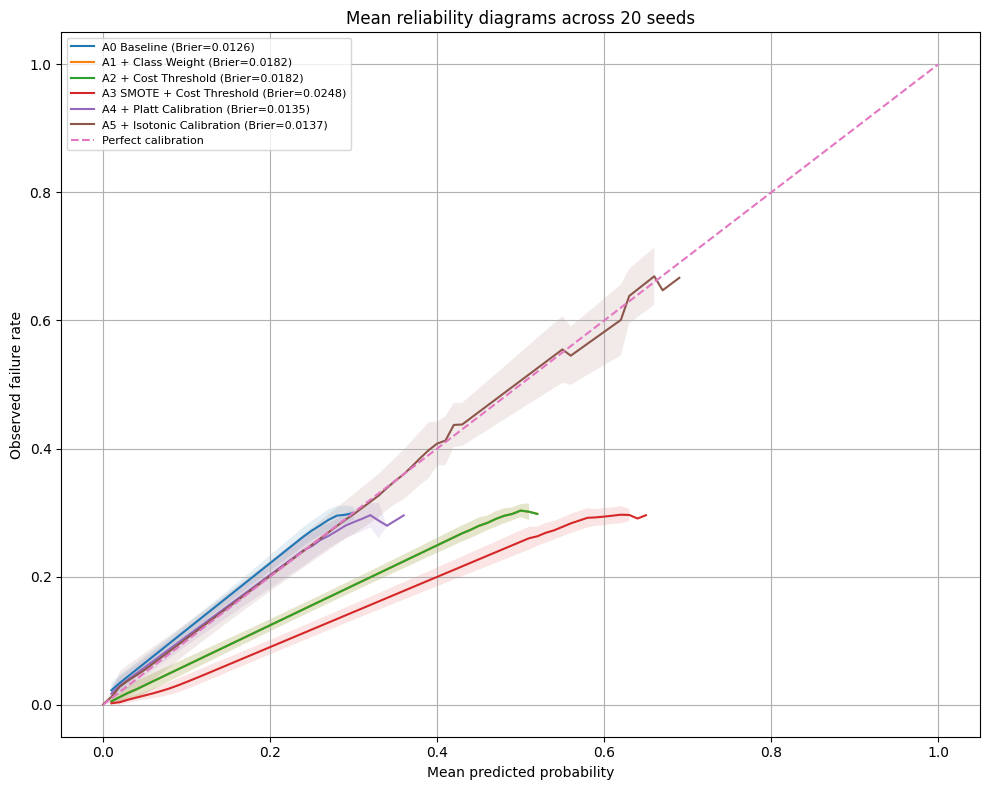

In [ ]:
# Reliability diagrams averaged across seeds
pprobability_grid = np.linspace(0.0, 1.0, 101)
averaged_curve_rows = []

plt.figure(figsize=(10, 8))

# Loop over ablations
for ablation in reliability_df["Ablation"].unique():
    group = reliability_df[reliability_df["Ablation"] == ablation]

    interpolated_curves = []

    # Interpolate each seed's reliability curve onto a common grid
    for seed in group["Seed"].unique():
        seed_curve = (
            group[group["Seed"] == seed]
            .sort_values("Mean_Predicted_Probability")
            .drop_duplicates("Mean_Predicted_Probability")
        )

        x_values = seed_curve["Mean_Predicted_Probability"].to_numpy(dtype=float)
        y_values = seed_curve["Observed_Failure_Rate"].to_numpy(dtype=float)

        # Skip seeds with insufficient points
        if len(x_values) < 2:
            continue

        interpolated = np.interp(
            probability_grid,
            x_values,
            y_values,
            left=np.nan,
            right=np.nan,
        )
        interpolated_curves.append(interpolated)

    interpolated_curves = np.asarray(interpolated_curves, dtype=float)

    # Mean & std across seeds
    mean_curve = np.nanmean(interpolated_curves, axis=0)
    std_curve = np.nanstd(interpolated_curves, axis=0, ddof=1)

    valid = ~np.isnan(mean_curve)

    # Retrieve mean Brier score for legend
    mean_brier = calibration_summary.loc[
        calibration_summary["Ablation"] == ablation,
        "Brier_Mean",
    ].iloc[0]

    # Plot mean reliability curve
    plt.plot(
        probability_grid[valid],
        mean_curve[valid],
        label=f"{ablation} (Brier={mean_brier:.4f})",
    )

    # Shaded ±1 std band
    lower_band = np.clip(mean_curve - std_curve, 0, 1)
    upper_band = np.clip(mean_curve + std_curve, 0, 1)

    plt.fill_between(
        probability_grid[valid],
        lower_band[valid],
        upper_band[valid],
        alpha=0.12,
    )

    # Store averaged curve rows
    for grid_value, mean_value, std_value in zip(
        probability_grid[valid],
        mean_curve[valid],
        std_curve[valid],
    ):
        averaged_curve_rows.append({
            "Ablation": ablation,
            "Probability_Grid": grid_value,
            "Observed_Rate_Mean": mean_value,
            "Observed_Rate_Std": std_value,
        })

# Perfect calibration reference line
plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed failure rate")
plt.title("Mean reliability diagrams across 20 seeds")
plt.grid(True)
plt.legend(fontsize=8)
plt.tight_layout()

# Save figure
plt.savefig(
    FIG / "calibration_reliability_diagrams_mean_20_seeds.png",
    dpi=300,
)

plt.show()

# Save averaged reliability curves
averaged_reliability_df = pd.DataFrame(averaged_curve_rows)

averaged_reliability_df.to_csv(
    OUT / "05b_averaged_reliability_curves.csv",
    index=False,
)

## Incremental ablation contributions

This section quantifies the incremental contribution of each ablation step.

For each pair of ablations (left → right):

*   Compute absolute delta for each metric.
*   Compute relative percentage change (delta / |left| * 100).

Purpose:
*   Show how each intervention affects predictive quality, operational cost, calibration reliability, and latency.
*   Provide interpretable, step-by-step understanding of model behaviour.



In [ ]:
# Define incremental ablation pairs
incremental_pairs = [
    ("A0 Baseline", "A1 + Class Weight", "Contribution of class weighting"),
    ("A1 + Class Weight", "A2 + Cost Threshold", "Contribution of cost-sensitive thresholding"),
    ("A2 + Cost Threshold", "A4 + Platt Calibration", "Contribution of Platt calibration"),
    ("A2 + Cost Threshold", "A5 + Isotonic Calibration", "Contribution of isotonic calibration"),
]

# Compute mean metrics for each ablation across seeds
mean_table = (
    ablation_df
    .groupby("Ablation")[SUMMARY_METRICS]
    .mean()
)

contribution_rows = []

# Compute incremental contributions for each ablation pair
for left, right, description in incremental_pairs:
    row = {
        "Comparison": f"{right} vs {left}",
        "Interpretation": description,
    }

    for metric in SUMMARY_METRICS:
        left_value = mean_table.loc[left, metric]
        right_value = mean_table.loc[right, metric]

        # Absolute change
        delta = right_value - left_value
        row[f"Delta_{metric}"] = delta

        # Relative percentage change
        if not np.isclose(left_value, 0):
            row[f"Relative_Change_Percent_{metric}"] = (delta / abs(left_value)) * 100
        else:
            row[f"Relative_Change_Percent_{metric}"] = np.nan

    contribution_rows.append(row)

# Convert to DataFrame
contribution_df = pd.DataFrame(contribution_rows)

# Save incremental contributions
contribution_df.to_csv(
    OUT / "06_ablation_incremental_contributions.csv",
    index=False,
)

# Display results
display(contribution_df)

,Comparison,Interpretation,Delta_F1,Relative_Change_Percent_F1,Delta_Recall,Relative_Change_Percent_Recall,Delta_Precision,Relative_Change_Percent_Precision,Delta_PR_AUC,Relative_Change_Percent_PR_AUC,...,Delta_Brier,Relative_Change_Percent_Brier,Delta_Log_Loss,Relative_Change_Percent_Log_Loss,Delta_ECE,Relative_Change_Percent_ECE,Delta_Total_Configuration_Fit_Time_Seconds,Relative_Change_Percent_Total_Configuration_Fit_Time_Seconds,Delta_Single_Sample_Latency_Median_ms,Relative_Change_Percent_Single_Sample_Latency_Median_ms
0,A1 + Class Weight vs A0 Baseline,Contribution of class weighting,-0.027458,-3.774746,0.158824,25.194401,-0.234374,-27.090710,-0.024627,-3.038437,...,0.005580,44.192109,0.016614,33.032215,0.014780,206.926808,-0.113083,-19.610528,0.464367,7.570617
1,A2 + Cost Threshold vs A1 + Class Weight,Contribution of cost-sensitive thresholding,-0.046002,-6.572190,0.023529,2.981366,-0.067020,-10.625052,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,A4 + Platt Calibration vs A2 + Cost Threshold,Contribution of Platt calibration,-0.004511,-0.689785,0.001961,0.241255,-0.006583,-1.167737,0.000000,0.000000,...,-0.004677,-25.684228,-0.013483,-20.149701,-0.013894,-63.376717,0.005344,1.152863,0.000000,0.000000
3,A5 + Isotonic Calibration vs A2 + Cost Threshold,Contribution of isotonic calibration,0.000298,0.045567,0.000000,0.000000,0.000141,0.025019,-0.046929,-5.971447,...,-0.004466,-24.529511,-0.000080,-0.120161,-0.015002,-68.429981,0.001102,0.237755,0.000000,0.000000


## Bootstrap figures

This section visualises bootstrap confidence intervals for **F1 score** and **Operational Cost**.

Using **ablation_summary** (computed in above code) and **95% bootstrap confidence intervals** (CI95_Low, CI95_High).

Purpose:
*   Provide interpretable uncertainty bands for each ablation.
*   Show how interventions affect predictive and operational stability.

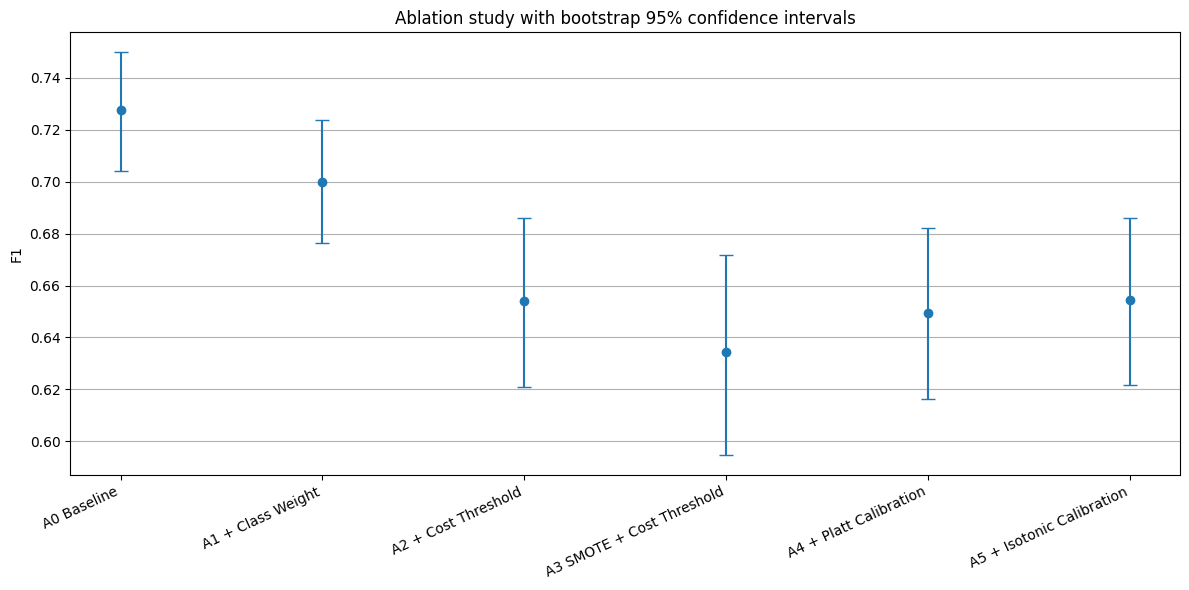

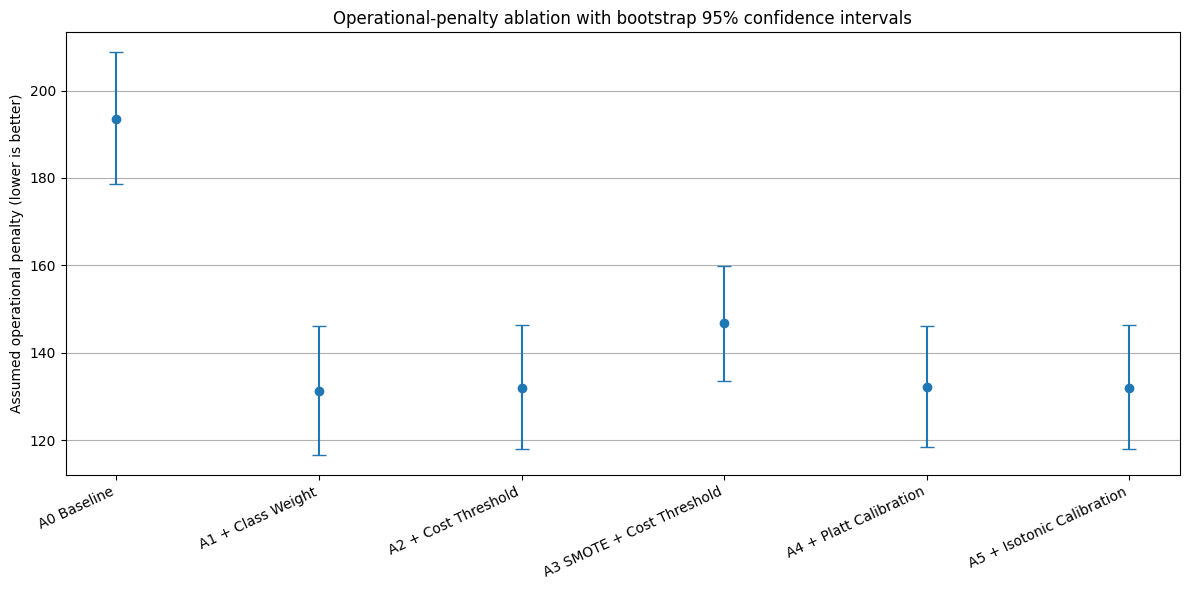

In [ ]:
# Copy summary table for plotting
plot_df = ablation_summary.copy()

# X-axis positions for ablation categories
x_positions = np.arange(len(plot_df))

# F1 score bootstrap CI figure
f1_means = plot_df["F1_Mean"].to_numpy()
f1_lower_error = f1_means - plot_df["F1_CI95_Low"].to_numpy()
f1_upper_error = plot_df["F1_CI95_High"].to_numpy() - f1_means

plt.figure(figsize=(12, 6))

# Error bar plot for F1
plt.errorbar(
    x_positions,
    f1_means,
    yerr=[f1_lower_error, f1_upper_error],
    fmt="o",
    capsize=5,
)

plt.xticks(
    x_positions,
    plot_df["Ablation"],
    rotation=25,
    ha="right",
)

plt.ylabel("F1")
plt.title("Ablation study with bootstrap 95% confidence intervals (F1)")
plt.grid(True, axis="y")
plt.tight_layout()

# Save figure
plt.savefig(
    FIG / "ablation_f1_bootstrap_ci.png",
    dpi=300,
)

plt.show()

# Operational Cost bootstrap CI figure
penalty_means = plot_df["Operational_Cost_Mean"].to_numpy()
penalty_lower_error = penalty_means - plot_df["Operational_Cost_CI95_Low"].to_numpy()
penalty_upper_error = plot_df["Operational_Cost_CI95_High"].to_numpy() - penalty_means

plt.figure(figsize=(12, 6))

# Error bar plot for Operational Cost
plt.errorbar(
    x_positions,
    penalty_means,
    yerr=[penalty_lower_error, penalty_upper_error],
    fmt="o",
    capsize=5,
)

plt.xticks(
    x_positions,
    plot_df["Ablation"],
    rotation=25,
    ha="right",
)

plt.ylabel("Assumed operational penalty (FP=1, FN=10)")
plt.title("Ablation study with bootstrap 95% confidence intervals (Operational Cost)")
plt.grid(True, axis="y")
plt.tight_layout()

# Save figure
plt.savefig(
    FIG / "ablation_operational_cost_bootstrap_ci.png",
    dpi=300,
)

plt.show()

## Direction-aware practical and statistical interpretation

This section interprets paired statistical results from previous section.

It focuses on two comparisons:
*  A4 + Platt Calibration vs A0 Baseline
*  A5 + Isotonic Calibration vs A0 Baseline

For each metric:

*   Determine practical direction (Improved / Worsened / No change)
*   Determine statistical significance (Holm-adjusted p < 0.05)
*   Provide recommended wording for reporting in the thesis

In [ ]:
# Metric direction classification sets
HIGHER_IS_BETTER = {
    "F1",
    "Recall",
    "Precision",
    "PR_AUC",
    "ROC_AUC",
}

LOWER_IS_BETTER = {
    "Operational_Cost",
    "Brier",
    "Log_Loss",
    "ECE",
}

# Interpretation function for paired metric changes
def interpret_metric_change(metric, mean_difference, adjusted_p):
    """
    Interpret paired metric change using:
      • Practical direction (Improved / Worsened / No change)
      • Statistical significance (Holm-adjusted p < 0.05)
      • Recommended wording for thesis reporting
    """

    # Missing difference → cannot interpret
    if pd.isna(mean_difference):
        return {
            "Practical_Direction": "Not available",
            "Statistically_Significant": False,
            "Recommended_Wording": (
                "The paired change could not be evaluated."
            ),
        }

    # Statistical significance check
    statistically_significant = (
        pd.notna(adjusted_p) and adjusted_p < 0.05
    )

    # Practical direction
    if np.isclose(mean_difference, 0):
        practical_direction = "No change"

    elif metric in HIGHER_IS_BETTER:
        practical_direction = "Improved" if mean_difference > 0 else "Worsened"

    elif metric in LOWER_IS_BETTER:
        practical_direction = "Improved" if mean_difference < 0 else "Worsened"

    else:
        practical_direction = "Not classified"

    # Recommended wording
    if practical_direction == "No change":
        wording = "No practical paired change was observed."

    elif statistically_significant and practical_direction == "Improved":
        wording = "Statistically supported favourable paired difference"

    elif statistically_significant and practical_direction == "Worsened":
        wording = "Statistically supported unfavourable paired difference"

    elif practical_direction == "Improved":
        wording = (
            "Practical favourable paired difference observed; "
            "not statistically significant after Holm correction"
        )

    elif practical_direction == "Worsened":
        wording = (
            "Practical unfavourable paired difference observed; "
            "not statistically significant after Holm correction"
        )

    else:
        wording = "Direction was not classified."

    return {
        "Practical_Direction": practical_direction,
        "Statistically_Significant": statistically_significant,
        "Recommended_Wording": wording,
    }

# Comparisons of interest (calibration vs baseline)
focus_comparisons = [
    "A4 + Platt Calibration vs A0 Baseline",
    "A5 + Isotonic Calibration vs A0 Baseline",
]

validation_rows = []

# Build validation summary table
for _, row in (
    tests_df[tests_df["Comparison"].isin(focus_comparisons)].iterrows()
):
    interpretation = interpret_metric_change(
        metric=row["Metric"],
        mean_difference=row["Mean_Difference_Right_Minus_Left"],
        adjusted_p=row["Holm_Adjusted_p"],
    )

    validation_rows.append({
        "Comparison": row["Comparison"],
        "Metric": row["Metric"],
        "Mean_Difference": row["Mean_Difference_Right_Minus_Left"],
        "Practical_Direction": interpretation["Practical_Direction"],
        "Cohens_dz": row["Cohens_dz"],
        "Effect_Size_Magnitude": row["Effect_Size_Magnitude"],
        "Holm_Adjusted_p": row["Holm_Adjusted_p"],
        "Statistically_Significant": interpretation["Statistically_Significant"],
        "Recommended_Wording": interpretation["Recommended_Wording"],
    })

# Convert to DataFrame
validation_summary = pd.DataFrame(validation_rows)

# Save summary
validation_summary.to_csv(
    OUT / "07_statistical_validation_summary.csv",
    index=False,
)

# Display summary
display(validation_summary)

,Comparison,Metric,Mean_Difference,Practical_Direction,Cohens_dz,Effect_Size_Magnitude,Holm_Adjusted_p,Statistically_Significant,Recommended_Wording
0,A4 + Platt Calibration vs A0 Baseline,F1,-0.077971,Worsened,-0.767519,Medium,0.087859,False,Practical unfavourable paired difference obser...
1,A5 + Isotonic Calibration vs A0 Baseline,F1,-0.073162,Worsened,-0.741914,Medium,0.118616,False,Practical unfavourable paired difference obser...
2,A4 + Platt Calibration vs A0 Baseline,Recall,0.184314,Improved,3.014072,Large,0.001622,True,Statistically supported favourable paired diff...
3,A5 + Isotonic Calibration vs A0 Baseline,Recall,0.182353,Improved,3.053914,Large,0.001622,True,Statistically supported favourable paired diff...
4,A4 + Platt Calibration vs A0 Baseline,PR_AUC,-0.024627,Worsened,-1.568184,Large,0.000401,True,Statistically supported unfavourable paired di...
5,A5 + Isotonic Calibration vs A0 Baseline,PR_AUC,-0.071556,Worsened,-2.610447,Large,0.000046,True,Statistically supported unfavourable paired di...
6,A4 + Platt Calibration vs A0 Baseline,Operational_Cost,-61.300000,Improved,-2.142877,Large,0.000719,True,Statistically supported favourable paired diff...
7,A5 + Isotonic Calibration vs A0 Baseline,Operational_Cost,-61.600000,Improved,-2.211101,Large,0.000719,True,Statistically supported favourable paired diff...
8,A4 + Platt Calibration vs A0 Baseline,Brier,0.000904,Worsened,1.692038,Large,0.000069,True,Statistically supported unfavourable paired di...
9,A5 + Isotonic Calibration vs A0 Baseline,Brier,0.001114,Worsened,1.509948,Large,0.000095,True,Statistically supported unfavourable paired di...


## Notebook 2 Summary

In [ ]:
# Identify best configurations for key criteria
# Highest mean F1 score
best_f1 = (
    ablation_summary
    .sort_values("F1_Mean", ascending=False)
    .iloc[0]
)

# Lowest mean operational penalty
best_penalty = (
    ablation_summary
    .sort_values("Operational_Cost_Mean")
    .iloc[0]
)

# Lowest mean Brier score
best_brier = (
    ablation_summary
    .sort_values("Brier_Mean")
    .iloc[0]
)

# Lowest mean ECE
best_ece = (
    ablation_summary
    .sort_values("ECE_Mean")
    .iloc[0]
)

# Build automatic validation report table
automatic_report = pd.DataFrame(
    [
        {
            "Criterion": "Highest mean F1",
            "Configuration": best_f1["Ablation"],
            "Value": best_f1["F1_Mean"],
        },
        {
            "Criterion": "Lowest mean assumed operational penalty",
            "Configuration": best_penalty["Ablation"],
            "Value": best_penalty["Operational_Cost_Mean"],
        },
        {
            "Criterion": "Lowest mean Brier score",
            "Configuration": best_brier["Ablation"],
            "Value": best_brier["Brier_Mean"],
        },
        {
            "Criterion": "Lowest mean ECE",
            "Configuration": best_ece["Ablation"],
            "Value": best_ece["ECE_Mean"],
        },
        {
            "Criterion": "Number of Holm-significant tests",
            "Configuration": "All paired comparisons",
            "Value": int(tests_df["Significant_0.05"].sum()),
        },
    ]
)

# Save automatic validation report
automatic_report.to_csv(
    OUT / "08_automatic_validation_report.csv",
    index=False,
)

# Display report
display(automatic_report)

,Criterion,Configuration,Value
0,Highest mean F1,A0 Baseline,0.727409
1,Lowest mean assumed operational penalty,A1 + Class Weight,131.350000
2,Lowest mean Brier score,A0 Baseline,0.012628
3,Lowest mean ECE,A5 + Isotonic Calibration,0.006921
4,Number of Holm-significant tests,All paired comparisons,27.000000


## Final interpretation

This notebook supports the following defensible conclusions:

1. Repeated seeds quantify variability and paired evidence; they do not improve the model.
2. Class weighting, threshold optimisation, SMOTE and calibration are the interventions that produce changes.
3. Wilcoxon tests evaluate whether the median paired difference differs from zero.
4. Cohen's \(d_z\) describes the magnitude of paired differences.
5. Holm correction controls family-wise multiplicity separately for predictive, operational and calibration outcomes.
6. A statistically supported difference is not automatically a favourable difference.
7. Statistical significance alone does not establish research novelty.
8. The notebook validates the consistency of framework components within AI4I; it does not establish external industrial validity.